In [1]:
import pandas as pd

In [2]:
train = pd.read_csv(
    "../data/raw/goemotions/data/train.tsv",
    sep="\t",
    header=None,
    names=["text","labels","id"]
)

dev = pd.read_csv(
    "../data/raw/goemotions/data/dev.tsv",
    sep="\t",
    header=None,
    names=["text", "labels", "id"]
)

test = pd.read_csv(
    "../data/raw/goemotions/data/test.tsv",
    sep="\t",
    header=None,
    names=["text", "labels", "id"]
)

In [3]:
print("Train :", train.shape)
print("Dev   :", dev.shape)
print("Test  :", test.shape)

Train : (43410, 3)
Dev   : (5426, 3)
Test  : (5427, 3)


In [4]:
train.head(10)

,text,labels,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,26,edvnz26
6,Yes I heard abt the f bombs! That has to be wh...,15,ee3b6wu
7,We need more boards and to create a bit more s...,"8,20",ef4qmod
8,Damn youtube and outrage drama is super lucrat...,0,ed8wbdn
9,It might be linked to the trust factor of your...,27,eczgv1o


In [5]:
train["num_labels"] = train["labels"].astype(str).apply(
    lambda x: len(x.split(","))
)

train["num_labels"].value_counts().sort_index()

num_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64

In [6]:
train = train[train["num_labels"] == 1].copy()
dev = dev[dev["labels"].astype(str).apply(lambda x: len(x.split(",")) == 1)].copy()
test = test[test["labels"].astype(str).apply(lambda x: len(x.split(",")) == 1)].copy()

In [7]:
train["labels"] = train["labels"].astype(int)
dev["labels"] = dev["labels"].astype(int)
test["labels"] = test["labels"].astype(int)

In [8]:
print(train.shape)
print(dev.shape)
print(test.shape)

(36308, 4)
(4548, 3)
(4590, 3)


In [9]:
import json

with open("../data/raw/goemotions/data/ekman_mapping.json", "r") as f:
    ekman_mapping = json.load(f)

print(type(ekman_mapping))
print(ekman_mapping)

<class 'dict'>
{'anger': ['anger', 'annoyance', 'disapproval'], 'disgust': ['disgust'], 'fear': ['fear', 'nervousness'], 'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'pride', 'admiration', 'desire', 'caring'], 'sadness': ['sadness', 'disappointment', 'embarrassment', 'grief', 'remorse'], 'surprise': ['surprise', 'realization', 'confusion', 'curiosity']}


In [10]:
reverse_mapping = {}

for ekman_emotion, emotions in ekman_mapping.items():

    for emotion in emotions:

        reverse_mapping[emotion] = ekman_emotion

print(reverse_mapping)

{'anger': 'anger', 'annoyance': 'anger', 'disapproval': 'anger', 'disgust': 'disgust', 'fear': 'fear', 'nervousness': 'fear', 'joy': 'joy', 'amusement': 'joy', 'approval': 'joy', 'excitement': 'joy', 'gratitude': 'joy', 'love': 'joy', 'optimism': 'joy', 'relief': 'joy', 'pride': 'joy', 'admiration': 'joy', 'desire': 'joy', 'caring': 'joy', 'sadness': 'sadness', 'disappointment': 'sadness', 'embarrassment': 'sadness', 'grief': 'sadness', 'remorse': 'sadness', 'surprise': 'surprise', 'realization': 'surprise', 'confusion': 'surprise', 'curiosity': 'surprise'}


In [11]:
emotion_names = []

with open("../data/raw/goemotions/data/emotions.txt","r") as f:

    emotion_names = [line.strip() for line in f]

print(len(emotion_names))

print(emotion_names)

28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [12]:
id_to_emotion = {
    i: emotion
    for i, emotion in enumerate(emotion_names)
}

id_to_emotion

{0: 'admiration',
 1: 'amusement',
 2: 'anger',
 3: 'annoyance',
 4: 'approval',
 5: 'caring',
 6: 'confusion',
 7: 'curiosity',
 8: 'desire',
 9: 'disappointment',
 10: 'disapproval',
 11: 'disgust',
 12: 'embarrassment',
 13: 'excitement',
 14: 'fear',
 15: 'gratitude',
 16: 'grief',
 17: 'joy',
 18: 'love',
 19: 'nervousness',
 20: 'optimism',
 21: 'pride',
 22: 'realization',
 23: 'relief',
 24: 'remorse',
 25: 'sadness',
 26: 'surprise',
 27: 'neutral'}

In [13]:
train["emotion"] = train["labels"].map(id_to_emotion)

dev["emotion"] = dev["labels"].map(id_to_emotion)

test["emotion"] = test["labels"].map(id_to_emotion)

In [14]:
train["ekman"] = train["emotion"].map(reverse_mapping)

dev["ekman"] = dev["emotion"].map(reverse_mapping)

test["ekman"] = test["emotion"].map(reverse_mapping)

In [15]:
print(train["ekman"].isna().sum())

print(dev["ekman"].isna().sum())

print(test["ekman"].isna().sum())

12823
1592
1606


In [16]:
reverse_mapping["neutral"] = "neutral"

In [17]:
train["ekman"] = train["emotion"].map(reverse_mapping)

dev["ekman"] = dev["emotion"].map(reverse_mapping)

test["ekman"] = test["emotion"].map(reverse_mapping)

In [18]:
train = train.dropna(subset=["ekman"]).reset_index(drop=True)
dev = dev.dropna(subset=["ekman"]).reset_index(drop=True)
test = test.dropna(subset=["ekman"]).reset_index(drop=True)

In [19]:
print(train["ekman"].value_counts())

ekman
joy         12920
neutral     12823
anger        3878
surprise     3553
sadness      2121
fear          515
disgust       498
Name: count, dtype: int64


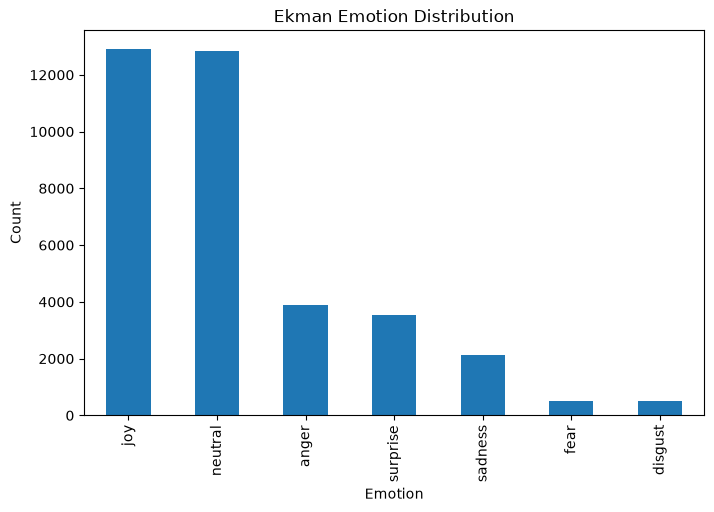

In [20]:
import matplotlib.pyplot as plt

train["ekman"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ekman Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train["label"] = label_encoder.fit_transform(train["ekman"])
dev["label"] = label_encoder.transform(dev["ekman"])
test["label"] = label_encoder.transform(test["ekman"])

In [22]:
import joblib
import os

os.makedirs("../models/emotion_detector", exist_ok=True)

joblib.dump(
    label_encoder,
    "../models/emotion_detector/label_encoder.pkl"
)

['../models/emotion_detector/label_encoder.pkl']

In [23]:
print(label_encoder.classes_)

['anger' 'disgust' 'fear' 'joy' 'neutral' 'sadness' 'surprise']


In [24]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train[["text", "label"]]
)

dev_dataset = Dataset.from_pandas(
    dev[["text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test[["text", "label"]]
)

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1636.09it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

In [27]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

dev_dataset = dev_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map: 100%|██████████| 4590/4590 [00:00<00:00, 11237.78 examples/s]


In [28]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

dev_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [29]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [30]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="../results/emotion",

    do_train=True,
    do_eval=True,

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    weight_decay=0.01,

    logging_steps=100,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none",

    seed=42
)

In [31]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=dev_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [32]:
trainer.train()

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.838422,0.808288,0.697010,0.696341,0.697010,0.695331
2,0.747358,0.799062,0.700528,0.704324,0.700528,0.701946
3,0.624179,0.855104,0.699868,0.699319,0.699868,0.699088


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.78it/s]
C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.09it/s]
C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.43it/s]


TrainOutput(global_step=6810, training_loss=0.7485925692643713, metrics={'train_runtime': 20464.0085, 'train_samples_per_second': 5.323, 'train_steps_per_second': 0.333, 'total_flos': 1803770690508288.0, 'train_loss': 0.7485925692643713, 'epoch': 3.0})

In [33]:
results = trainer.predict(test_dataset)

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [34]:
import numpy as np

predictions = np.argmax(results.predictions, axis=1)

true_labels = results.label_ids

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.53      0.55      0.54       520
     disgust       0.63      0.45      0.52        76
        fear       0.65      0.77      0.70        77
         joy       0.82      0.81      0.81      1603
     neutral       0.68      0.68      0.68      1606
     sadness       0.66      0.59      0.62       259
    surprise       0.56      0.63      0.59       449

    accuracy                           0.70      4590
   macro avg       0.65      0.64      0.64      4590
weighted avg       0.70      0.70      0.70      4590



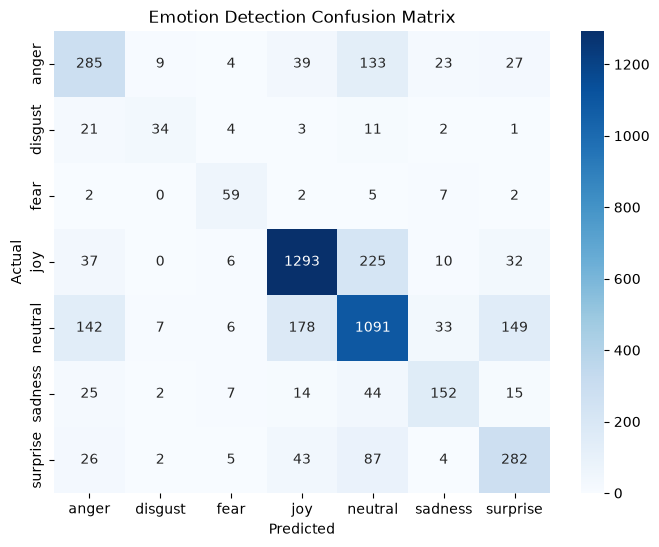

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Detection Confusion Matrix")

plt.show()

In [37]:
model.save_pretrained("../models/emotion_detector")

tokenizer.save_pretrained("../models/emotion_detector")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]


('../models/emotion_detector\\tokenizer_config.json',
 '../models/emotion_detector\\tokenizer.json')

In [38]:
import joblib

joblib.dump(
    label_encoder,
    "../models/emotion_detector/label_encoder.pkl"
)

['../models/emotion_detector/label_encoder.pkl']

In [2]:
import pandas as pd
import torch
import joblib

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
)

MODEL_DIR = "../models/emotion_detector"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)

label_encoder = joblib.load(f"{MODEL_DIR}/label_encoder.pkl")

model.eval()

C:\Users\Shristy\anaconda3\envs\ai-support\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1792.34it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [4]:
tickets = pd.read_csv("../data/processed/clean_customer_support_dataset.csv")
sample = tickets.sample(30, random_state=42)["initial_message"].tolist()
 
model.eval()
 
def predict_emotion(text):
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, padding="max_length", max_length=64
    )
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)[0]
    top = torch.topk(probs, k=2)
    return [
        (label_encoder.inverse_transform([idx.item()])[0], round(score.item() * 100, 1))
        for idx, score in zip(top.indices, top.values)
    ]
 
for text in sample:
    preds = predict_emotion(text)
    print(f"{text}\n  -> {preds}\n")

i need help but i m not sure which category this fits in.
  -> [('surprise', 84.0), ('neutral', 6.6)]

my account was locked after multiple failed login attempts.
  -> [('neutral', 55.8), ('sadness', 30.6)]

i cannot log in  the system says my password is incorrect.
  -> [('neutral', 55.1), ('anger', 39.1)]

i am seeing an error message when i click on data export.
  -> [('neutral', 57.1), ('anger', 19.5)]

my 2fa code is not working when i try to sign in.
  -> [('anger', 50.1), ('neutral', 32.0)]

the billing feature is not saving my changes.
  -> [('anger', 59.0), ('neutral', 37.0)]

i cannot log in  the system says my password is incorrect.
  -> [('neutral', 55.1), ('anger', 39.1)]

i need help but i m not sure which category this fits in.
  -> [('surprise', 84.0), ('neutral', 6.6)]

can you add an option to customize data export?
  -> [('surprise', 69.6), ('neutral', 26.7)]

i downgraded my plan but i am still being billed for the higher tier.
  -> [('neutral', 56.1), ('anger', 16.

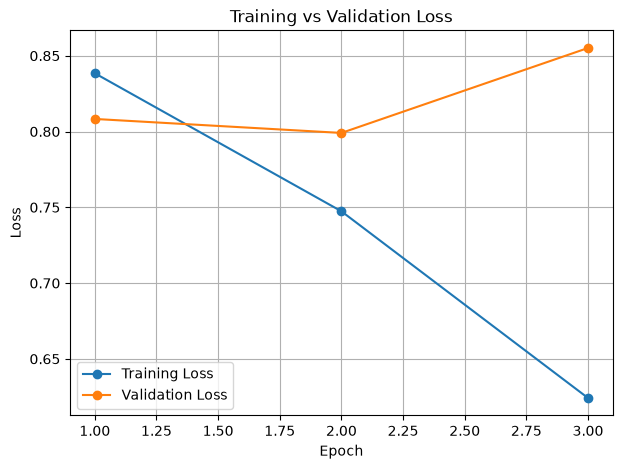

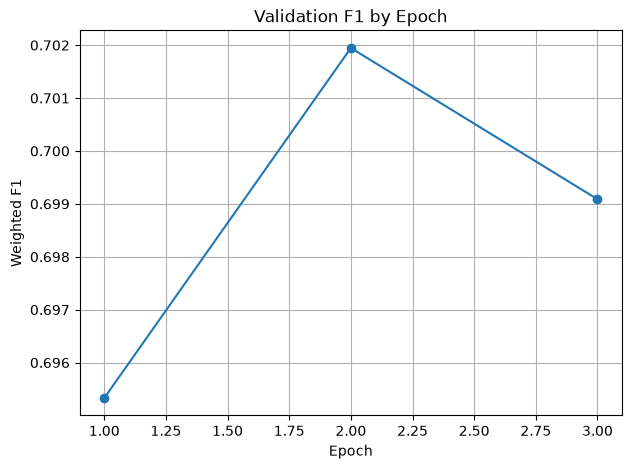

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame({
    "epoch": [1, 2, 3],
    "train_loss": [0.838422, 0.747358, 0.624179],
    "val_loss": [0.808288, 0.799062, 0.855104],
    "accuracy": [0.697010, 0.700528, 0.699868],
    "precision": [0.696341, 0.704324, 0.699319],
    "recall": [0.697010, 0.700528, 0.699868],
    "f1": [0.695331, 0.701946, 0.699088]
})

# ---------------- Loss Curve ----------------

plt.figure(figsize=(7,5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# ---------------- F1 Curve ----------------

plt.figure(figsize=(7,5))
plt.plot(history["epoch"], history["f1"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("Validation F1 by Epoch")
plt.grid(True)
plt.show()